In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"]=(8,5)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/hassanali789/student-stress-and-study-behavior-dataset/student_stress_dataset.csv


In [2]:
df=pd.read_csv("/kaggle/input/datasets/hassanali789/student-stress-and-study-behavior-dataset/student_stress_dataset.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id                  100 non-null    int64 
 1   study_hours         100 non-null    int64 
 2   sleep_hours         100 non-null    int64 
 3   social_media_hours  100 non-null    int64 
 4   exam_score          100 non-null    int64 
 5   stress_level        100 non-null    object
dtypes: int64(5), object(1)
memory usage: 4.8+ KB


In [4]:
df.head()

,id,study_hours,sleep_hours,social_media_hours,exam_score,stress_level
0,1,2,6,5,55,High
1,2,5,7,2,75,Low
2,3,1,5,6,45,High
3,4,4,6,3,70,Medium
4,5,6,8,1,85,Low


In [5]:
df.describe()

,id,study_hours,sleep_hours,social_media_hours,exam_score
count,100.000000,100.000000,100.000000,100.000000,100.000000
mean,50.500000,3.500000,6.080000,3.830000,64.350000
std,29.011492,1.743675,1.177911,2.098845,16.481624
min,1.000000,1.000000,4.000000,1.000000,39.000000
25%,25.750000,2.000000,5.000000,2.000000,48.000000
50%,50.500000,3.500000,6.000000,3.500000,64.500000
75%,75.250000,5.000000,7.000000,6.000000,79.250000
max,100.000000,7.000000,8.000000,7.000000,90.000000


In [6]:
df.isnull().sum()

id                    0
study_hours           0
sleep_hours           0
social_media_hours    0
exam_score            0
stress_level          0
dtype: int64

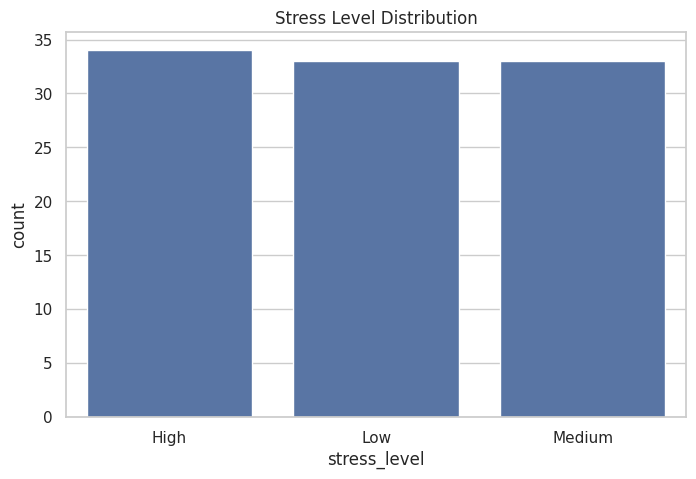

In [7]:
sns.countplot(data=df, x="stress_level")
plt.title("Stress Level Distribution")
plt.show()

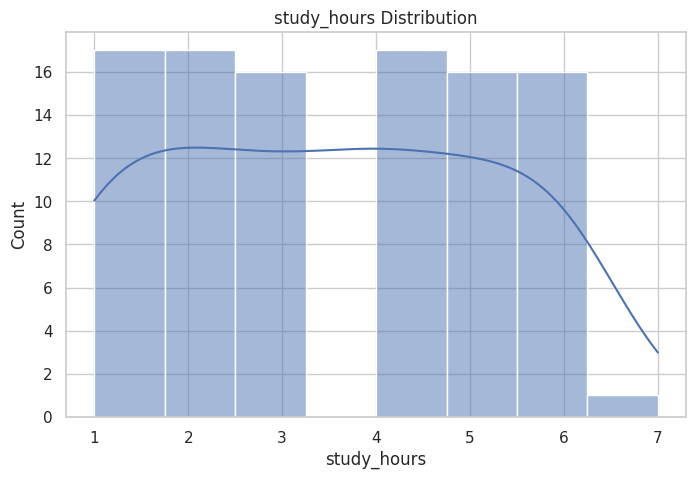

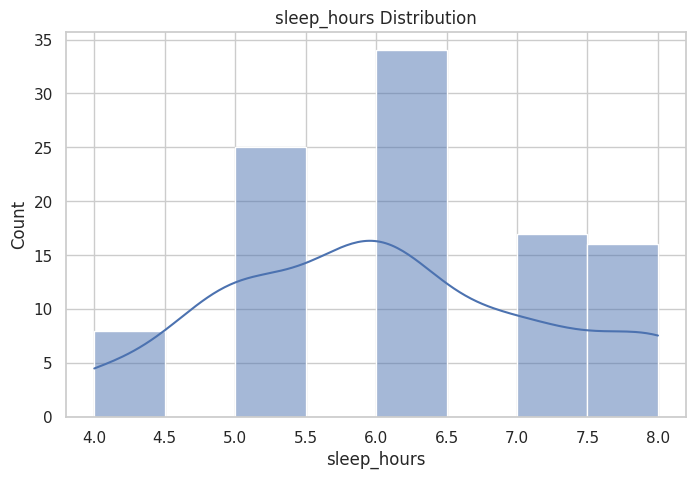

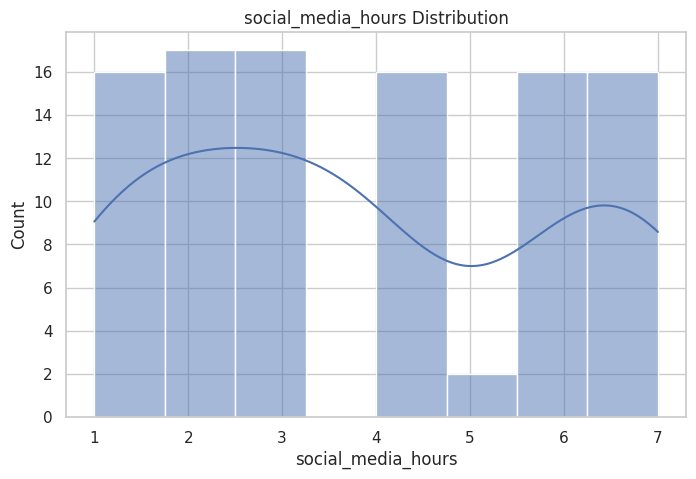

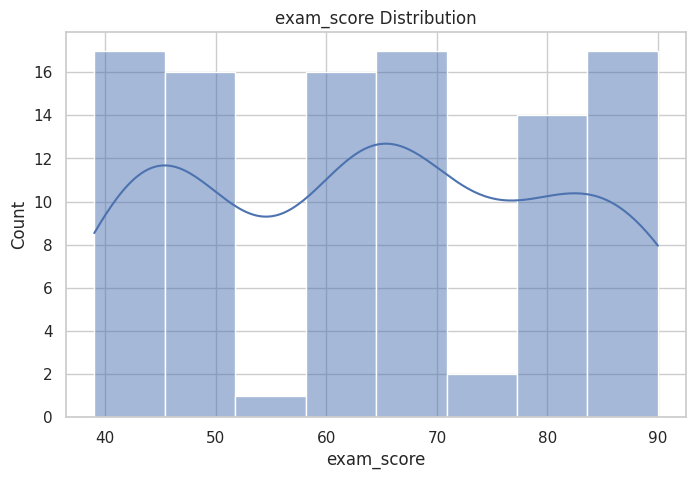

In [8]:
num_cols=["study_hours", "sleep_hours", "social_media_hours", "exam_score"]

for col in num_cols:
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} Distribution")
    plt.show()

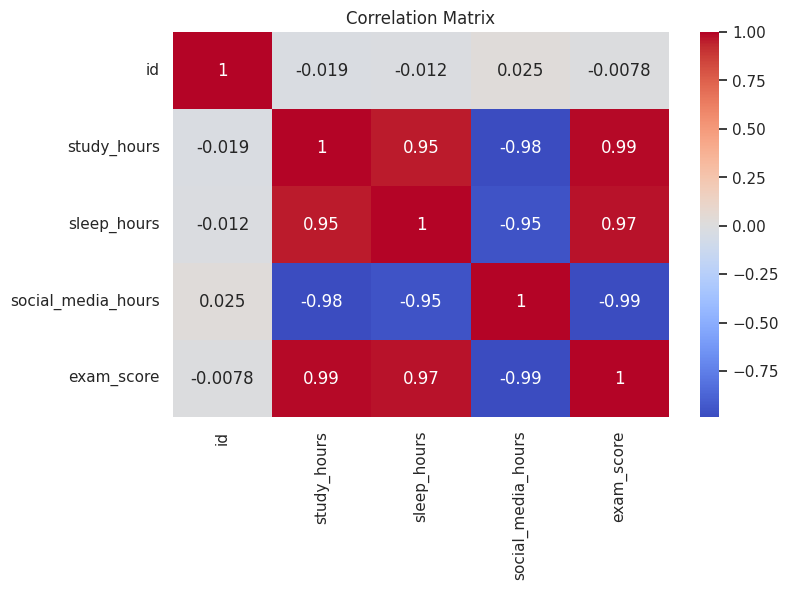

In [9]:
corr=df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

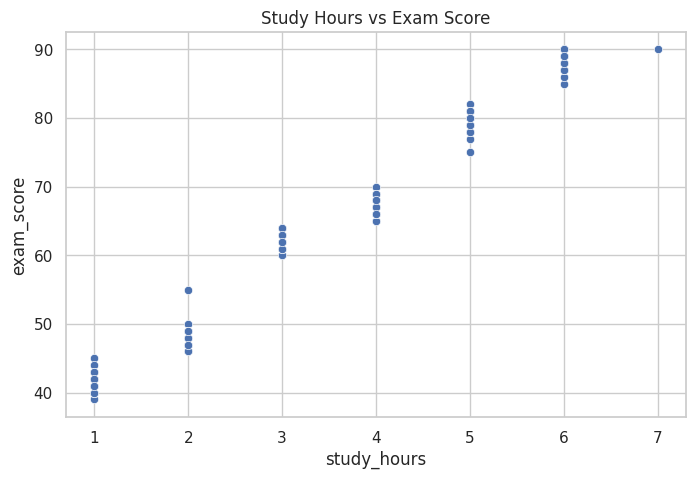

In [10]:
sns.scatterplot(data=df, x="study_hours", y="exam_score")
plt.title("Study Hours vs Exam Score")
plt.show()

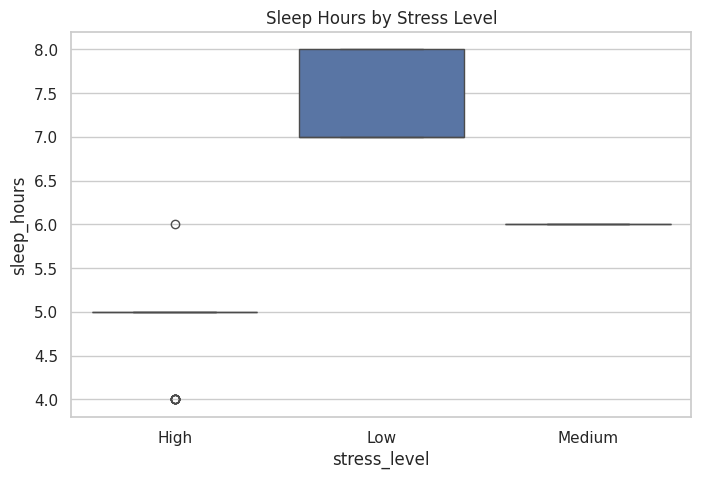

In [11]:
sns.boxplot(data=df, x="stress_level", y="sleep_hours")
plt.title("Sleep Hours by Stress Level")
plt.show()

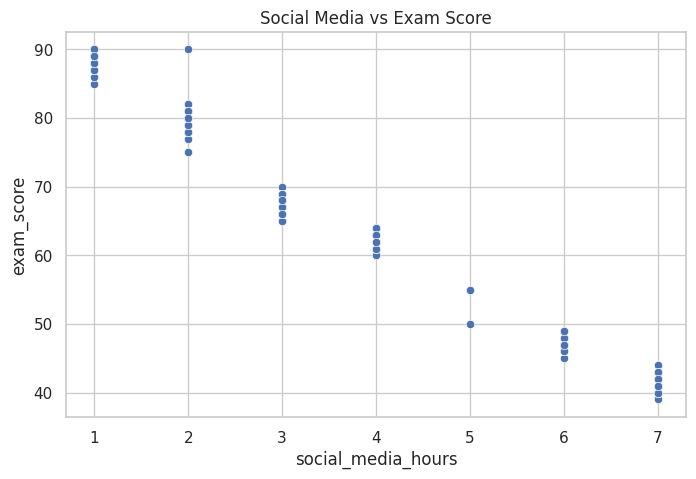

In [12]:
sns.scatterplot(data=df, x="social_media_hours", y="exam_score")
plt.title("Social Media vs Exam Score")
plt.show()

In [13]:
from sklearn.preprocessing import LabelEncoder

df_encoded=df.copy()
le=LabelEncoder()

df_encoded["stress_level"]=le.fit_transform(df_encoded["stress_level"])

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

X=df_encoded.drop(["stress_level", "id"], axis=1)
y=df_encoded["stress_level"]

X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2)

model=RandomForestClassifier()
model.fit(X_train, y_train)

preds=model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      1.00      1.00         4
           2       1.00      1.00      1.00         7

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



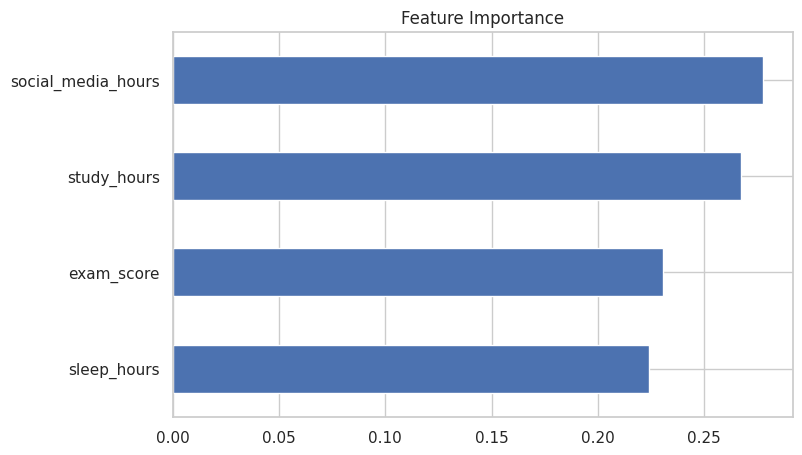

In [15]:
importance=pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.show()

Key Insights:

* Increased study hours are positively correlated with higher exam scores
* Excessive social media usage negatively impacts academic performance
* Lower sleep duration is associated with higher stress levels
* Balanced study and sleep routines lead to better outcomes
* Stress levels can be reasonably predicted using behavioral features